# Which filters carry the information? A band-ablation study

A survey has to choose filters, and a stellar-parameter pipeline has to say
what each one buys. This notebook answers that empirically on the real TSLTE
grid: **remove bands, watch the posterior widen.**

The plan:

1. **The precomputed bands** — six survey groups in the grid.
2. **Survey-group ablation** — what does each survey deliver on its own, and
   what does a metallicity-sensitive narrow band add on top?
3. **Inside LSST and inside DES** — per-band leave-one-out and cumulative
   u → g → r → i, so a survey person sees which of *their* filters carries the
   metallicity.
4. **Global leave-one-out** across all 21 bands.
5. **Where the fast method breaks** — as bands are removed the posterior goes
   non-Gaussian, so every headline number is cross-checked against nested
   sampling.

~60 posterior fits in a couple of minutes. The data is threaded as a *traced*
argument (masked bands get zero weight rather than a shorter array), so a
single compiled graph serves every band subset — no recompile per scenario.

**The fits run on nested sampling, not the fast Laplace path.** An ablation
study deliberately removes information, which is precisely when the posterior
stops being Gaussian; the first draft of this notebook used Laplace and got a
nonsense answer (see §6). Speed is worthless if the answer is wrong.

In [1]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from tengri import Uniform

from tengri_stars import (
    StarModel,
    load_photometry_grid,
    make_laplace_pipeline,
    make_nss_pipeline,
    overlay_corner,
)

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(29)

DATA = (
    Path("data") if (Path("data") / "TSLTE_combined_photometry.fits").exists() else Path("../data")
)

## 1. The precomputed bands

`TSLTE_combined_photometry.fits` carries 21 pre-integrated AB magnitudes.
Note two things an LSST audience should hear up front:

- **LSST here is *ugri* only** — the grid has no z or y. Every LSST statement
  below is about the blue/optical half of the real filter set.
- **SkyMapper contributes a `v` band** (violet, metallicity-sensitive) — the
  only narrow-ish metallicity probe in the table besides CaHK, which makes
  `skymapper_v` vs `CaHK` a natural head-to-head.

In [2]:
grid = load_photometry_grid(DATA / "TSLTE_combined_photometry.fits", fill="nearest")
model = StarModel(grid=grid, interp_method="pchip")
ALL_BANDS = list(grid.filter_names)


def pick(*fragments):
    return [b for b in ALL_BANDS if any(f in b for f in fragments)]


GROUPS = {
    "LSST": pick("lsst_"),
    "DES/DECam": pick("DECCAM_"),
    "SkyMapper": pick("skymapper_"),
    "SDSS": pick("SLOAN-SDSS"),
    "HST": pick("HST_"),
    "CaHK": pick("CaHK"),
}
for name, bands in GROUPS.items():
    print(f"{name:11s} ({len(bands)}): {', '.join(bands)}")
assert sum(len(b) for b in GROUPS.values()) == len(ALL_BANDS)

LSST        (4): lsst_g_ab, lsst_u_ab, lsst_i_ab, lsst_r_ab
DES/DECam   (4): DECCAM_i_des_ab, DECCAM_u_des_ab, DECCAM_r_des_ab, DECCAM_g_des_ab
SkyMapper   (5): skymapper_i_ab, skymapper_g_ab, skymapper_u_ab, skymapper_r_ab, skymapper_v_ab
SDSS        (4): SLOAN-SDSS.i_ab, SLOAN-SDSS.g_ab, SLOAN-SDSS.r_ab, SLOAN-SDSS.u_ab
HST         (3): HST_WFC3_UVIS1.F336W_ab, HST_ACS_WFC.F475W_ab, HST_ACS_WFC.F814W_ab
CaHK        (1): CaHK_filter_ab


## 2. The star, the priors, and one fit per band subset

A metal-poor giant — the regime these surveys care about. Masked-out bands get
zero weight rather than a shorter array, so the compiled graph never changes
shape and every subset reuses one program.

In [3]:
SIG_MAG = 0.02
TRUTH = {"teff": 4600.0, "logg": 1.5, "feh": -2.0, "mu": -18.0}
PARAMS = ["teff", "logg", "feh", "mu"]

mags_all = jnp.asarray(
    np.asarray(model.predict_mags(**TRUTH)) + rng.normal(0.0, SIG_MAG, len(ALL_BANDS))
)
lo_hi = [(float(a[0]), float(a[-1])) for a in grid.axes]
priors = {
    "teff": Uniform(*lo_hi[0]),
    "logg": Uniform(*lo_hi[1]),
    "feh": Uniform(*lo_hi[2]),
    "mu": Uniform(TRUTH["mu"] - 10.0, TRUTH["mu"] + 10.0),
}


def loglikelihood(p, data):
    mags, weights = data
    pred = model.predict_mags(teff=p["teff"], logg=p["logg"], feh=p["feh"], mu=p["mu"])
    return -0.5 * jnp.sum(weights * (pred - mags) ** 2)


laplace = make_laplace_pipeline(loglikelihood, priors, n_samples=2000)
nss = make_nss_pipeline(loglikelihood, priors, n_live=400, num_delete=40)


def weights_for(bands):
    """Inverse variance: 1/sigma^2 for bands in use, 0 for bands dropped."""
    keep = np.isin(ALL_BANDS, list(bands))
    return jnp.asarray(np.where(keep, 1.0 / SIG_MAG**2, 0.0))


def fit(bands, key=0, sampler=None):
    """Posterior for one band subset → (sigma per parameter, median, samples).

    Defaults to **nested sampling**, not Laplace. That is a deliberate, and
    hard-won, choice: an ablation study *removes information*, which is exactly
    when a posterior stops being Gaussian and the optimizer behind Laplace can
    land on the wrong peak. Using the fast method here produced a nonsense
    ranking (one band appearing to carry a 13x inflation in sigma([Fe/H]), which
    no single filter can when twenty others remain). Section 6 shows the failure
    directly. Laplace is for throughput once a configuration is validated; the
    science below runs on the sampler that explores.
    """
    sampler = sampler or nss
    samples, _info = sampler(jax.random.PRNGKey(key), (mags_all, weights_for(bands)))
    sig = {p: float(np.std(np.asarray(samples[p]))) for p in PARAMS}
    med = {p: float(np.median(np.asarray(samples[p]))) for p in PARAMS}
    return sig, med, samples


t0 = time.time()
sig_full, med_full, samples_full = fit(ALL_BANDS)
t_nss = time.time() - t0
t0 = time.time()
_ = fit(ALL_BANDS, sampler=laplace)
t_lap = time.time() - t0
print(f"one fit: NSS {t_nss:.1f} s (incl. compile) | Laplace {t_lap:.1f} s")
print("truth:", {k: round(v, 2) for k, v in TRUTH.items()})
print("all 21 bands: " + "  ".join(f"sigma({p})={sig_full[p]:.3f}" for p in PARAMS))

one fit: NSS 4.5 s (incl. compile) | Laplace 3.0 s
truth: {'teff': 4600.0, 'logg': 1.5, 'feh': -2.0, 'mu': -18.0}
all 21 bands: sigma(teff)=59.625  sigma(logg)=0.488  sigma(feh)=0.114  sigma(mu)=0.076


## 3. Survey groups: what does each survey deliver, and what does CaHK add?

Each survey **alone**, then each survey **plus CaHK**. This is the question a
survey team actually asks: *is one narrow filter worth it?*

survey      n | sigma[Fe/H]   +CaHK   gain | sigma(logg)   +CaHK
LSST        4 |       0.405   0.223   1.8x |       1.830   1.011
DES/DECam   4 |       0.264   0.232   1.1x |       1.824   1.499
SkyMapper   5 |       0.379   0.243   1.6x |       1.021   0.674
SDSS        4 |       0.453   0.272   1.7x |       1.542   1.137
HST         3 |       0.863   0.231   3.7x |       1.288   0.890


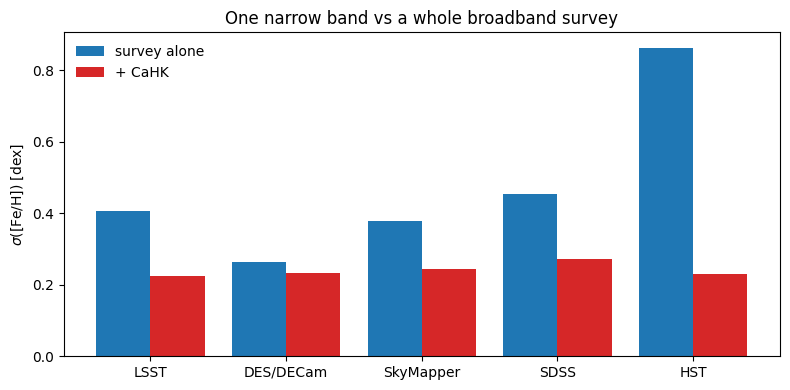

In [4]:
rows = []
for name, bands in GROUPS.items():
    if name == "CaHK":
        continue
    sig_a, med_a, _ = fit(bands, key=1)
    sig_b, med_b, _ = fit(bands + GROUPS["CaHK"], key=1)
    rows.append((name, len(bands), sig_a, med_a, sig_b, med_b))

print(
    f"{'survey':<11s}{'n':>2s} | {'sigma[Fe/H]':>11s}{'+CaHK':>8s}{'gain':>7s} | "
    f"{'sigma(logg)':>11s}{'+CaHK':>8s}"
)
for name, n, sa, _ma, sb, _mb in rows:
    print(
        f"{name:<11s}{n:2d} | {sa['feh']:11.3f}{sb['feh']:8.3f}{sa['feh'] / sb['feh']:6.1f}x | "
        f"{sa['logg']:11.3f}{sb['logg']:8.3f}"
    )

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(rows))
ax.bar(x - 0.2, [r[2]["feh"] for r in rows], 0.4, label="survey alone", color="C0")
ax.bar(x + 0.2, [r[4]["feh"] for r in rows], 0.4, label="+ CaHK", color="C3")
ax.set_xticks(x, [r[0] for r in rows])
ax.set(ylabel=r"$\sigma$([Fe/H]) [dex]", title="One narrow band vs a whole broadband survey")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 4. Inside LSST and inside DES

Two views per survey: **cumulative** (add filters bluest-first, watch σ fall)
and **leave-one-out** (drop each filter from the full set — how unique is it?).

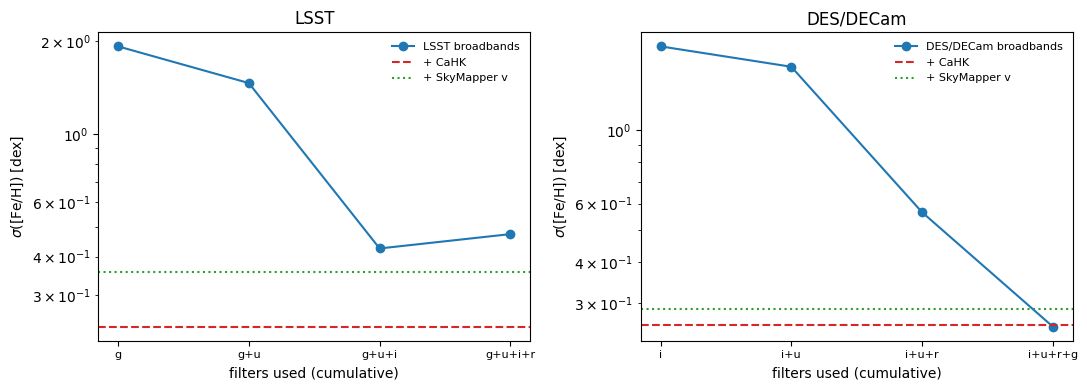


LSST: leave-one-out (sigma without band / sigma with all 4)


  drop lsst_g_ab              sigma([Fe/H]) x1.81   sigma(Teff) x0.58


  drop lsst_u_ab              sigma([Fe/H]) x2.31   sigma(Teff) x0.67


  drop lsst_i_ab              sigma([Fe/H]) x1.06   sigma(Teff) x0.85


  drop lsst_r_ab              sigma([Fe/H]) x1.26   sigma(Teff) x0.81



DES/DECam: leave-one-out (sigma without band / sigma with all 4)


  drop DECCAM_i_des_ab        sigma([Fe/H]) x1.68   sigma(Teff) x0.73


  drop DECCAM_u_des_ab        sigma([Fe/H]) x5.14   sigma(Teff) x0.70


  drop DECCAM_r_des_ab        sigma([Fe/H]) x1.04   sigma(Teff) x0.84


  drop DECCAM_g_des_ab        sigma([Fe/H]) x1.93   sigma(Teff) x1.05


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, survey in zip(axes, ["LSST", "DES/DECam"]):
    bands = GROUPS[survey]
    cumulative, labels = [], []
    for k in range(1, len(bands) + 1):
        sig, _, _ = fit(bands[:k], key=2)
        cumulative.append(sig["feh"])
        labels.append("+".join(b.split("_")[1][:1] for b in bands[:k]))
    with_cahk, _, _ = fit(bands + GROUPS["CaHK"], key=2)
    with_smv, _, _ = fit(bands + pick("skymapper_v"), key=2)

    ax.plot(range(1, len(bands) + 1), cumulative, "o-", color="C0", label=f"{survey} broadbands")
    ax.axhline(with_cahk["feh"], color="C3", ls="--", label="+ CaHK")
    ax.axhline(with_smv["feh"], color="C2", ls=":", label="+ SkyMapper v")
    ax.set(
        xlabel="filters used (cumulative)",
        ylabel=r"$\sigma$([Fe/H]) [dex]",
        title=survey,
        yscale="log",
    )
    ax.set_xticks(range(1, len(bands) + 1), labels, fontsize=8)
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

for survey in ["LSST", "DES/DECam"]:
    bands = GROUPS[survey]
    sig_all, _, _ = fit(bands, key=3)
    print(f"\n{survey}: leave-one-out (sigma without band / sigma with all {len(bands)})")
    for band in bands:
        sig, _, _ = fit([b for b in bands if b != band], key=3)
        print(
            f"  drop {band:22s} sigma([Fe/H]) x{sig['feh'] / sig_all['feh']:.2f}   "
            f"sigma(Teff) x{sig['teff'] / sig_all['teff']:.2f}"
        )

## 5. Global leave-one-out: all 21 bands

Remove each band from the *full* set. What inflates σ([Fe/H]) is information
no other filter in the table supplies.

21 leave-one-out fits in 54 s


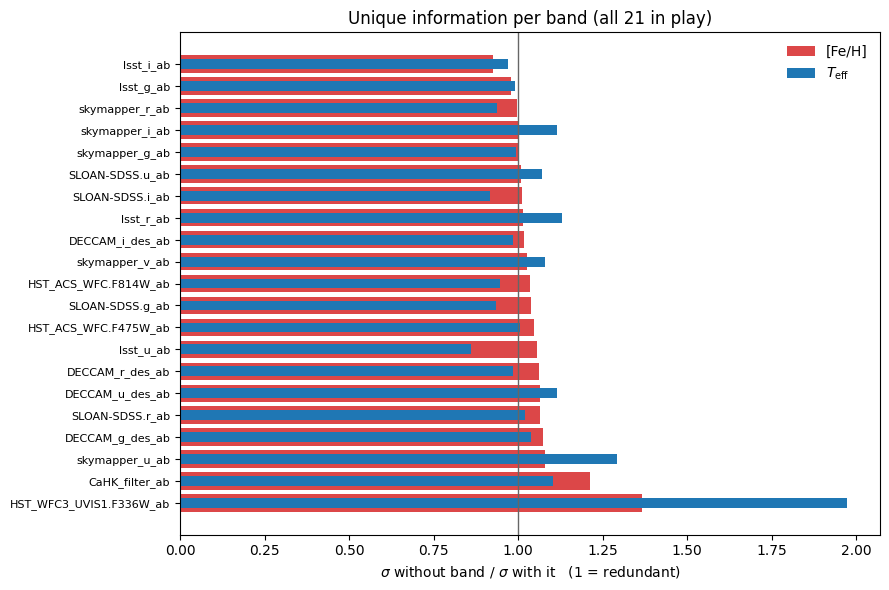

hardest bands to lose (by [Fe/H]):
  HST_WFC3_UVIS1.F336W_ab      x1.37
  CaHK_filter_ab               x1.21
  skymapper_u_ab               x1.08
  DECCAM_g_des_ab              x1.07
  SLOAN-SDSS.r_ab              x1.07
  DECCAM_u_des_ab              x1.06


In [6]:
t0 = time.time()
loo = {}
for band in ALL_BANDS:
    sig, _, _ = fit([b for b in ALL_BANDS if b != band], key=4)
    loo[band] = {p: sig[p] / sig_full[p] for p in PARAMS}
print(f"{len(ALL_BANDS)} leave-one-out fits in {time.time() - t0:.0f} s")

order = sorted(ALL_BANDS, key=lambda b: -loo[b]["feh"])
fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(order))
ax.barh(y, [loo[b]["feh"] for b in order], color="C3", alpha=0.85, label="[Fe/H]")
ax.barh(y, [loo[b]["teff"] for b in order], height=0.45, color="C0", label=r"$T_{\rm eff}$")
ax.axvline(1.0, color="0.4", lw=1)
ax.set_yticks(y, order, fontsize=8)
ax.set_xlabel(r"$\sigma$ without band $/$ $\sigma$ with it   (1 = redundant)")
ax.set_title("Unique information per band (all 21 in play)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("hardest bands to lose (by [Fe/H]):")
for b in order[:6]:
    print(f"  {b:28s} x{loo[b]['feh']:.2f}")

## 6. Survey scenarios — and why the fast method cannot be trusted here

Realistic configurations, each fit **twice**: nested sampling and the Laplace
pipeline that is ~20x faster. Watch what happens as bands are removed.

In [7]:
SCENARIOS = {
    "DES gri": pick("DECCAM_g", "DECCAM_r", "DECCAM_i"),
    "DES gri + CaHK": pick("DECCAM_g", "DECCAM_r", "DECCAM_i", "CaHK"),
    "LSST ugri": GROUPS["LSST"],
    "LSST ugri + CaHK": GROUPS["LSST"] + GROUPS["CaHK"],
    "all 21 bands": ALL_BANDS,
}

scen = {}
print(f"{'scenario':<18s}{'n':>2s} | {'[Fe/H] Laplace':>22s} | {'[Fe/H] NSS':>22s}")
for name, bands in SCENARIOS.items():
    sl, ml, samp_l = fit(bands, key=5, sampler=laplace)
    sn, mn, samp_n = fit(bands, key=5, sampler=nss)
    scen[name] = (samp_l, samp_n)
    print(
        f"{name:<18s}{len(bands):2d} | {ml['feh']:10.2f} +- {sl['feh']:<8.2f} | "
        f"{mn['feh']:10.2f} +- {sn['feh']:<8.2f}"
    )
print(f"\ntruth [Fe/H] = {TRUTH['feh']:.2f}")

scenario           n |         [Fe/H] Laplace |             [Fe/H] NSS


DES gri            3 |      -0.44 +- 0.71     |      -1.46 +- 1.42    


DES gri + CaHK     4 |      -2.36 +- 0.04     |      -2.04 +- 0.27    


LSST ugri          4 |      -2.35 +- 0.34     |      -2.53 +- 0.58    


LSST ugri + CaHK   5 |      -2.08 +- 0.27     |      -2.31 +- 0.22    


all 21 bands      21 |      -2.10 +- 0.23     |      -2.05 +- 0.11    

truth [Fe/H] = -2.00


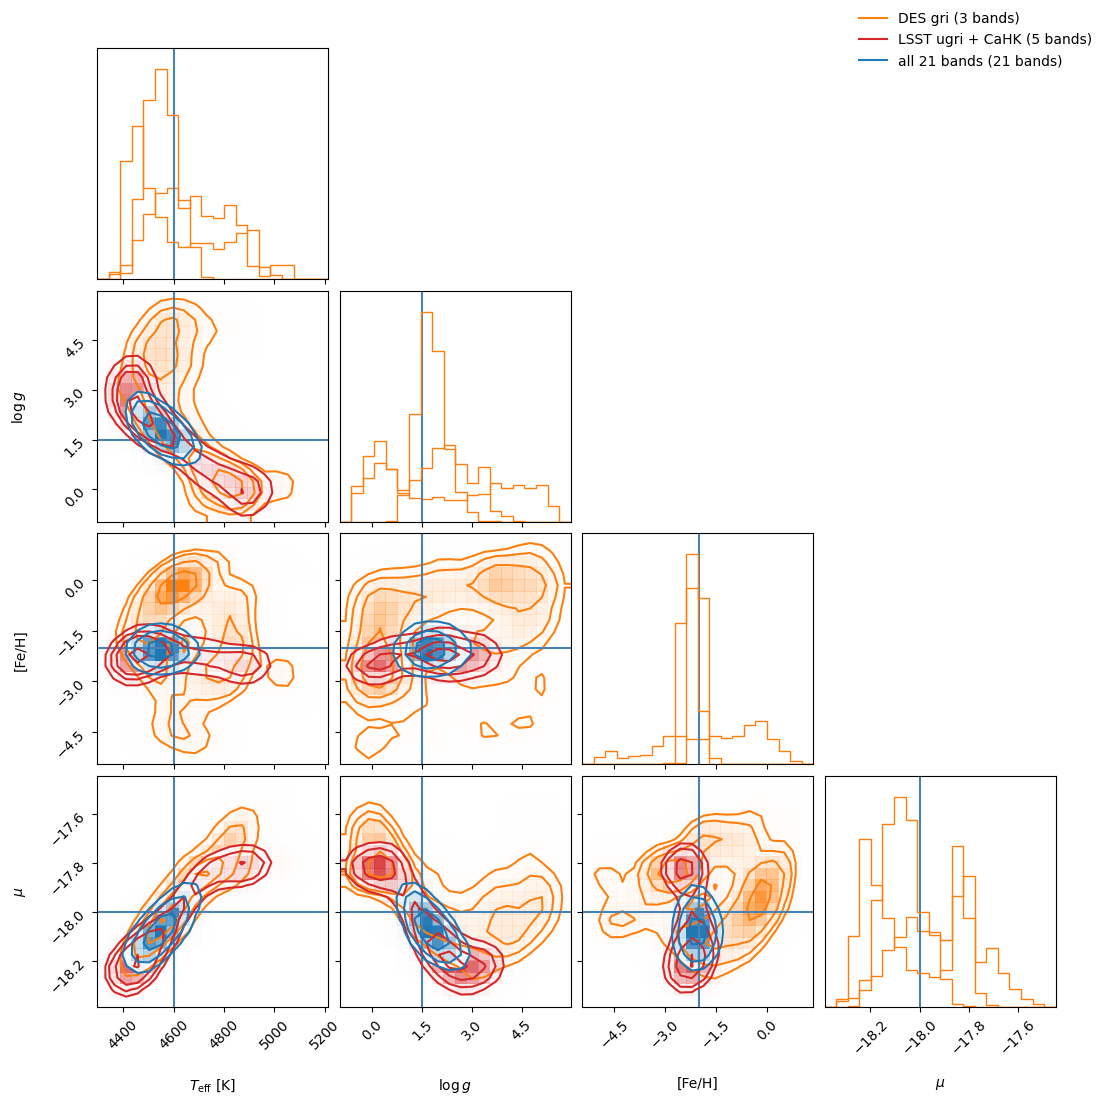

In [8]:
show = ["DES gri", "LSST ugri + CaHK", "all 21 bands"]
fig = overlay_corner(
    [scen[s][1] for s in show],  # nested sampling — the trustworthy posterior
    names=PARAMS,
    labels=[r"$T_{\rm eff}$ [K]", r"$\log g$", "[Fe/H]", r"$\mu$"],
    colors=["C1", "C3", "C0"],
    legend_labels=[f"{s} ({len(SCENARIOS[s])} bands)" for s in show],
    truths=TRUTH,
)
plt.show()

### The Gaussian's failure mode, made explicit

For the sparsest set the two methods part company. Nested sampling maps a
broad, skewed posterior; Laplace expands around one peak and quotes a tight
error bar around it.

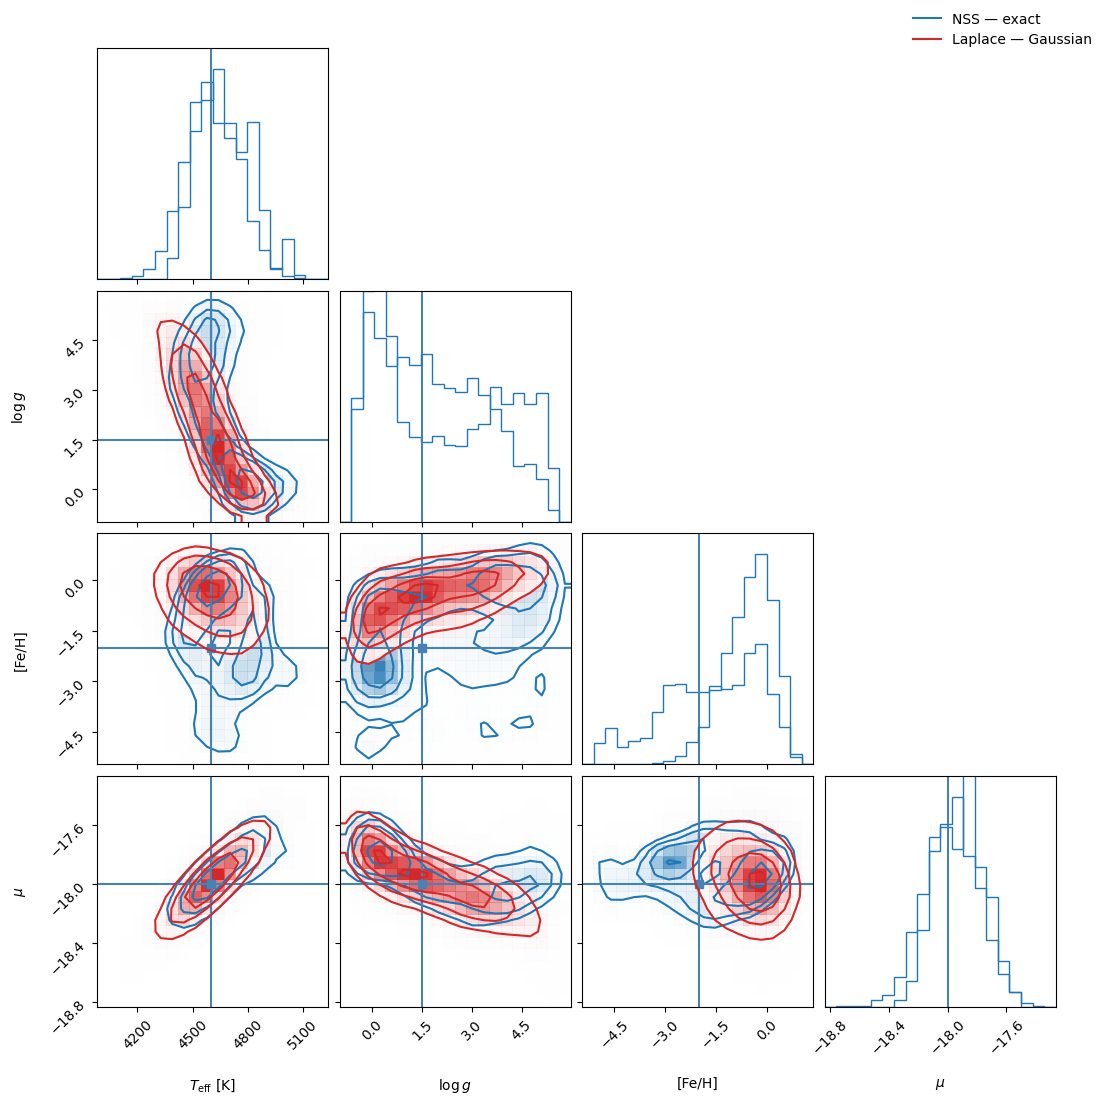

teff  Laplace   4608.32 +- 142.597   NSS   4666.16 +- 147.835   truth   4600.00
logg  Laplace      1.69 +-   1.543   NSS      1.84 +-   1.896   truth      1.50
feh   Laplace     -0.44 +-   0.711   NSS     -1.46 +-   1.425   truth     -2.00
mu    Laplace    -17.97 +-   0.185   NSS    -17.90 +-   0.158   truth    -18.00


In [9]:
lap_gri, nss_gri = scen["DES gri"]
fig = overlay_corner(
    [nss_gri, lap_gri],
    names=PARAMS,
    labels=[r"$T_{\rm eff}$ [K]", r"$\log g$", "[Fe/H]", r"$\mu$"],
    colors=["C0", "C3"],
    legend_labels=["NSS — exact", "Laplace — Gaussian"],
    truths=TRUTH,
)
plt.show()

for p in PARAMS:
    ln, nn = np.asarray(lap_gri[p]), np.asarray(nss_gri[p])
    print(
        f"{p:5s} Laplace {np.median(ln):9.2f} +- {np.std(ln):7.3f}   "
        f"NSS {np.median(nn):9.2f} +- {np.std(nn):7.3f}   truth {TRUTH[p]:9.2f}"
    )

## What to take away

Measured on this metal-poor giant ([Fe/H] = −2.0, log g = 1.5, σ = 0.02 mag),
with nested sampling throughout:

- **Metallicity lives in the near-UV.** Within LSST, dropping *u* inflates
  σ([Fe/H]) by **2.3×**; within DES, dropping *u* inflates it by **5.1×**. The
  red bands are nearly redundant for [Fe/H] — they buy temperature, not
  composition. Across all 21 bands the hardest to lose are HST F336W (×1.37)
  and CaHK (×1.21); the inflation is modest only because twenty other filters
  remain to cover for them.
- **A broadband set without *u* cannot measure metallicity.** DES *gri* gives
  [Fe/H] = −1.5 ± 1.4 dex against a truth of −2.0 — an error bar as wide as
  the entire metal-poor regime.
- **One narrow filter rescues it.** Adding CaHK to DES *gri* takes σ([Fe/H])
  from **1.4 → 0.27 dex** — a 5× gain from a single filter, and the design
  argument behind MAGIC, here measured rather than asserted. Adding CaHK to
  LSST *ugri* still helps (0.58 → 0.22 dex) even though *u* is already there.
- **The fast method lies exactly where it matters.** On DES *gri* — the
  degenerate configuration — Laplace reports [Fe/H] = −0.44 ± 0.71 while the
  exact posterior is −1.46 ± 1.42. A Gaussian expanded around one peak cannot
  see a broad, skewed posterior. Ablation studies *remove* information, so
  they are precisely the wrong place to trust it: use the sampler that
  explores, and reserve Laplace for validated, information-rich configurations.

**Caveats.** LSST in this grid is *ugri* only — no z or y, so the real filter
set is better than shown here. One star, one noise level, no extinction, and
the grid's own systematics (notebook 04) are excluded. Everything is one
rerun away: swap the star, the noise, or the filter list and the study takes
a couple of minutes.